In [2]:
def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 14
bound = 5
output = elliptic_fourier_expansions(level, bound)
print(len(output))
print()
print(output)
print()
print(output[0])
print()
print(output[0][1])

1

[('14a1', [(1, 1), (2, -1), (3, -2), (4, 1), (5, 0)])]

('14a1', [(1, 1), (2, -1), (3, -2), (4, 1), (5, 0)])

[(1, 1), (2, -1), (3, -2), (4, 1), (5, 0)]


In [3]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 14
bound = 401
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
print("expansion[:5]:",expansion[:5])

label: 14a1
expansion[:5]: [(1, 1), (2, -1), (3, -2), (4, 1), (5, 0)]


In [4]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 14
bound =2800
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
coeffs_list=[pair[1] for pair in expansion]

    
h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    print((n,j_n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run18mar26no51.txt', 'wb') as wfile:
    pickle.dump(expansion, wfile) 
    
with open('/Users/barrybrent/data2/run18mar26no52.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

label: 14a1
(1, 1)
(2, -3)
(3, -2)
(4, 5)
(5, -14)
(6, 30)
(7, -27)
(8, 21)
(9, 43)
(10, -118)
(11, 254)
(12, -370)
(13, 300)
(14, -31)
(15, -842)
(16, 2037)
(17, -3518)
(18, 4215)
(19, -2564)
(20, -3190)
(21, 15048)
(22, -31122)
(23, 46438)
(24, -45906)
(25, 9411)
(26, 86148)
(27, -249572)
(28, 446297)
(29, -573880)
(30, 427790)
(31, 255286)
(32, -1705419)
(33, 3863066)
(34, -6035870)
(35, 6550488)
(36, -2647585)
(37, -8819208)
(38, 29567740)
(39, -56399670)
(40, 76898826)
(41, -66066374)
(42, -11828920)
(43, 190283816)
(44, -471425202)
(45, 779684098)
(46, -911938986)
(47, 516199920)
(48, 842161518)
(49, -3456578019)
(50, 7050584207)
(51, -10189612118)
(52, 9773102916)
(53, -1111716604)
(54, -20637230460)
(55, 56893880194)
(56, -99714832567)
(57, 124808503018)
(58, -87511885296)
(59, -70956708896)
(60, 397348418510)
(61, -872796154662)
(62, 1335033898558)
(63, -1403272330515)
(64, 468319546805)
(65, 2152298030180)
(66, -6782965759782)
(67, 12630786627868)
(68, -16830848619918)
(69, 1

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


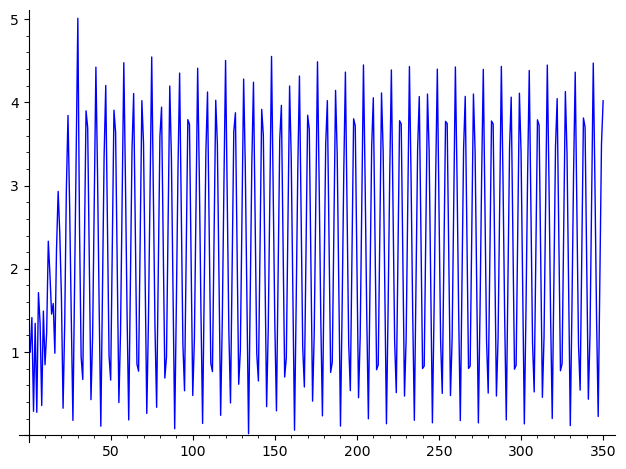

In [1]:
import pickle
from sage.all import sigma, nth_prime
import ast


with open('/Users/barrybrent/data2/run18mar26no52.txt', 'rb') as rfile:
    j_list = pickle.load(rfile)
    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    print(n)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run27mar26no23.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run27mar26no24.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run27mar26no25.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped


Data range: n = 1 to 350
Number of data points: 350
Min modulus range: 0.019040 to 5.010312

Detrending: Savitzky-Golay filter, window = 31, poly order = 3
  lag-1 autocorrelation of residuals = 0.4088
  Detrended data std dev: 1.1870

AR(1) lag-1 autocorrelation (rho): 0.4088
Frequency bins tested: 172
Bonferroni-corrected per-bin alpha: 95% -> 0.000291,  99% -> 0.000058

SIGNIFICANT PERIODICITIES  (period <= N/3 = 117, Bonferroni-corrected)
Rank   Period       Frequency    Power           Signif.   
---------------------------------------------------------------------------
1            5.65   0.177143     4.69e+04   99%

  Only one significant peak (period = 5.65); no ratios to compute.


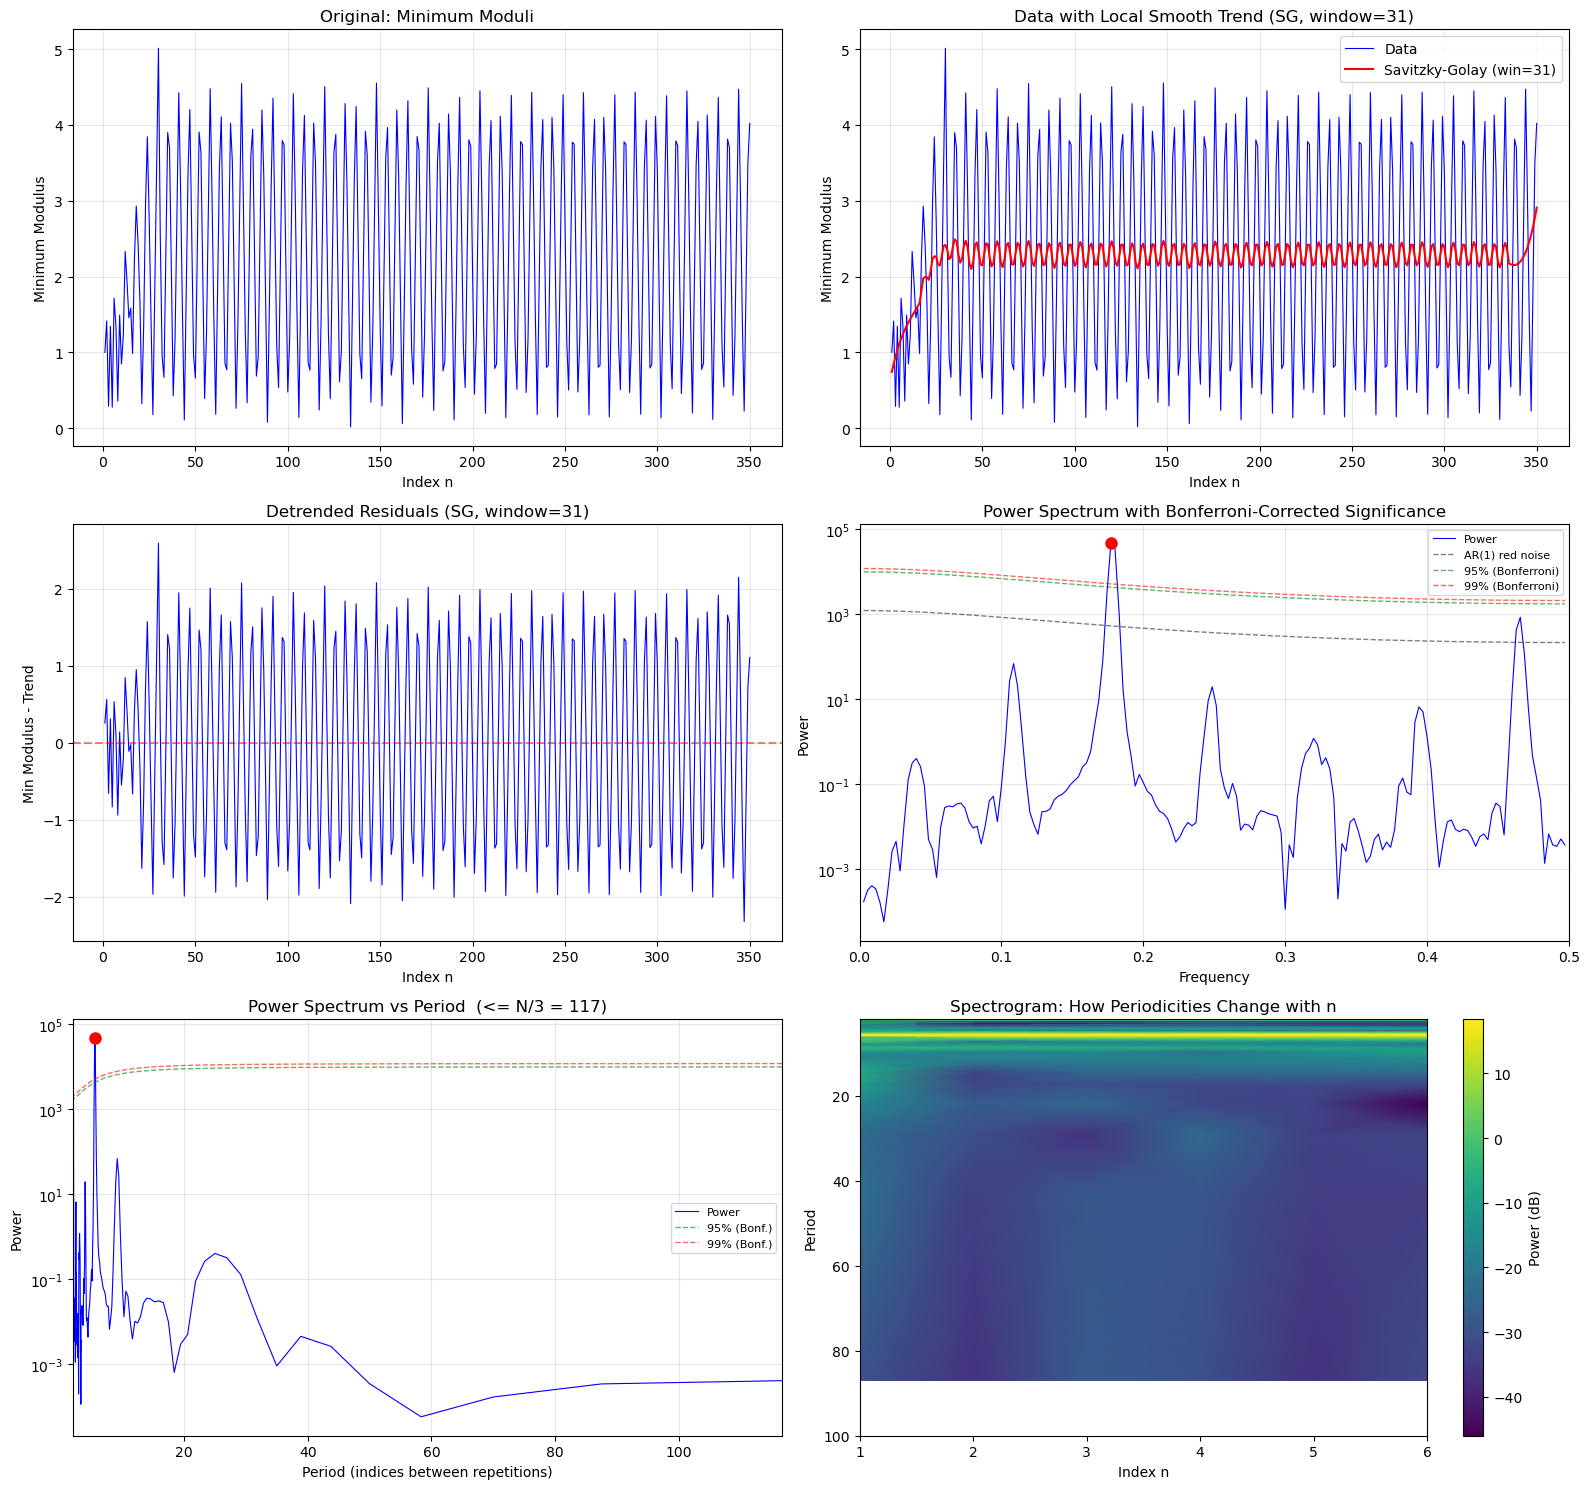


Analysis complete.


In [2]:
import pickle
with open('/Users/barrybrent/data2/run27mar26no25.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)

# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v4)
#
# Key fix in this version: MULTIPLE TESTING CORRECTION.
#
# With N/2 ~ 175 frequency bins, a 95% single-bin threshold will produce
# ~9 false positives purely by chance, even for white noise. Previous
# versions didn't account for this, so plateau noise peaks were
# incorrectly flagged as "significant periodicities."
#
# This version applies a Bonferroni correction: the per-bin significance
# level is divided by the number of independent frequency bins tested,
# so the *family-wise* false positive rate stays at 5% (or 1%).
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. LOCAL SMOOTHING DETREND  (Savitzky-Golay)
# ==============================================================================
sg_poly_order = 3

candidate_windows = [w for w in range(21, min(N//2, 151), 10) if w % 2 == 1]

best_win, best_score = candidate_windows[0], np.inf
sg_results = {}
for win in candidate_windows:
    trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
    resid = minmoduli - trend
    r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
    sg_results[win] = (trend, resid, r1)
    if r1 < best_score:
        best_score = r1
        best_win = win

smooth_trend, detrended, _ = sg_results[best_win]

print(f"\nDetrending: Savitzky-Golay filter, window = {best_win}, poly order = {sg_poly_order}")
print(f"  lag-1 autocorrelation of residuals = {best_score:.4f}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = detrended * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
variance = np.var(detrended)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
max_credible_period = N / 3.0
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
# Per-bin alpha = family_alpha / n_tests
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

print("\n" + "="*75)
print(f"SIGNIFICANT PERIODICITIES  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
    # Period ratios: fundamental (rank 1) to each subsequent peak
    if len(significant_peaks) >= 2:
        fund_idx = significant_peaks[0][0]
        fund_period = periods[fund_idx]
        print(f"\n{'':>6}PERIOD RATIOS  (fundamental / peak)")
        print(f"{'':>6}Fundamental period: {fund_period:.2f}")
        print(f"{'':>6}{'-'*55}")
        print(f"{'':>6}{'Rank':<6} {'Period':<12} {'T_fund / T_peak':<18} {'Nearest int':<12}")
        print(f"{'':>6}{'-'*55}")
        for rank, (pi, level) in enumerate(significant_peaks[1:15], 2):
            ratio = fund_period / periods[pi]
            nearest = round(ratio)
            print(f"{'':>6}{rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     {nearest:>6}")
    elif len(significant_peaks) == 1:
        print(f"\n  Only one significant peak (period = {periods[significant_peaks[0][0]]:.2f}); "
              f"no ratios to compute.")
else:
    print("  No peaks exceed the Bonferroni-corrected significance threshold.")
    print("  --> The data has no statistically significant periodicity.")
    print("  (Period ratios are not computed when no peaks are significant.)")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=f'Savitzky-Golay (win={best_win})')
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Local Smooth Trend (SG, window={best_win})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals (SG, window={best_win})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Power spectrum with corrected confidence bands
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[1, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[1, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[1, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[1, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)

# 6.5  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[2, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[2, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[2, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[2, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_credible_period)

# 6.6  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(detrended, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[2, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_credible_period))
axes[2, 1].invert_yaxis()
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)
